# 加利福尼亚房价

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch

# 加载加利福尼亚房价数据
california = fetch_california_housing(data_home = './data')
X = california.data          # 特征
y = california.target        # 房价

# 对特征进行归一化（标准化处理：均值为0，方差为1）
scaler = StandardScaler()
X = scaler.fit_transform(X)


# 封装为自定义的Dataset
class CaliforniaHousingDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1) # 变成列向量

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# 划分训练集、验证集和测试集
from sklearn.model_selection import train_test_split

# 先划分出测试集（20%），剩下的用于训练和验证
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 再从剩下的80%数据中划分出验证集（20%），即最终验证集占全体16%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# 分别构造训练集、验证集和测试集的Dataset
train_dataset = CaliforniaHousingDataset(X_train, y_train)
val_dataset = CaliforniaHousingDataset(X_val, y_val)
test_dataset = CaliforniaHousingDataset(X_test, y_test)

# 构造DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [2]:
train_dataset[0]

(tensor([ 0.4402, -0.1303,  0.4423,  0.0414, -0.4879,  0.0301,  1.1087, -0.6989]),
 tensor([1.7690]))

In [3]:
import torch.nn as nn

# 搭建回归模型，隐藏层30个神经元，输出层一个
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.net(x)

# 实例化模型
input_dim = X.shape[1]
model = RegressionModel(input_dim)

In [4]:
# 输出每层参数
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:5]}")

# 做一次前向计算
sample_X = torch.tensor(X_train[:1], dtype=torch.float32).unsqueeze(0)
output = model(sample_X)
print("前向计算输出: ", output)

Layer: net.0.weight | Size: torch.Size([30, 8]) | Values : tensor([[-0.0321,  0.1377,  0.3199,  0.2755,  0.1657,  0.1935,  0.2650, -0.2797],
        [ 0.1571, -0.0531,  0.0969, -0.3259, -0.2439, -0.3363,  0.3238,  0.2308],
        [ 0.1984, -0.1318,  0.0728,  0.0079, -0.3351,  0.2431, -0.3448, -0.1933],
        [-0.1173,  0.0438, -0.1455, -0.2699, -0.2318, -0.0904,  0.3361, -0.2755],
        [ 0.2332, -0.2121, -0.2121,  0.2650, -0.3049, -0.2017,  0.3329, -0.0483]],
       grad_fn=<SliceBackward0>)
Layer: net.0.bias | Size: torch.Size([30]) | Values : tensor([ 0.1753, -0.3497,  0.2622,  0.1321,  0.1962], grad_fn=<SliceBackward0>)
Layer: net.2.weight | Size: torch.Size([1, 30]) | Values : tensor([[ 0.0318,  0.1637, -0.1735, -0.1369,  0.0285, -0.0170, -0.1652, -0.0151,
         -0.0670, -0.1122,  0.0943, -0.1335, -0.1001,  0.1301, -0.0398, -0.1588,
         -0.0864, -0.1393,  0.0026,  0.0750, -0.0975, -0.1226, -0.0135, -0.0006,
         -0.0318,  0.0225,  0.0512, -0.0808,  0.0903,  0.0965

Epoch [1/100], Train Loss: 1.2292, Val Loss: 0.6575
Best regression model saved at epoch 1.
Epoch [2/100], Train Loss: 0.5155, Val Loss: 0.5083
Best regression model saved at epoch 2.
Epoch [3/100], Train Loss: 0.4640, Val Loss: 0.4893
Best regression model saved at epoch 3.
Epoch [4/100], Train Loss: 0.4483, Val Loss: 0.4692
Best regression model saved at epoch 4.
Epoch [5/100], Train Loss: 0.4352, Val Loss: 0.4568
Best regression model saved at epoch 5.
Epoch [6/100], Train Loss: 0.4231, Val Loss: 0.4446
Best regression model saved at epoch 6.
Epoch [7/100], Train Loss: 0.4142, Val Loss: 0.4372
Best regression model saved at epoch 7.
Epoch [8/100], Train Loss: 0.4079, Val Loss: 0.4333
Best regression model saved at epoch 8.
Epoch [9/100], Train Loss: 0.4000, Val Loss: 0.4244
Best regression model saved at epoch 9.
Epoch [10/100], Train Loss: 0.3901, Val Loss: 0.4130
Best regression model saved at epoch 10.
Epoch [11/100], Train Loss: 0.3834, Val Loss: 0.4156
No improvement. Early sto

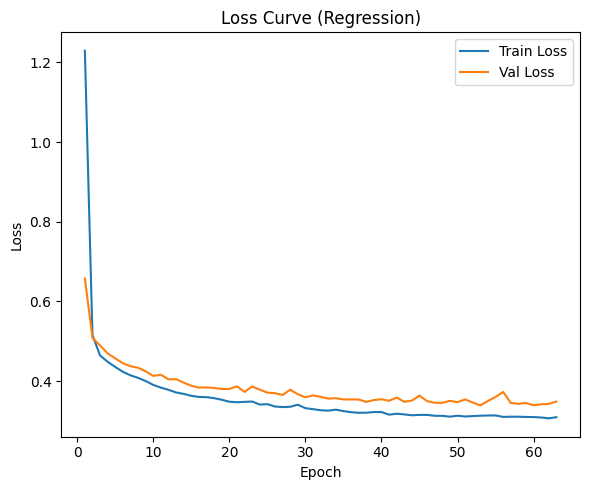

In [5]:
import torch.optim as optim
import torch.nn as nn

# 定义自定义损失函数，例如Huber损失
class CustomLoss(nn.Module):
    def __init__(self, delta=1.0):
        super(CustomLoss, self).__init__()
        self.delta = delta

    def forward(self, input, target):
        abs_error = torch.abs(input - target)
        quadratic = torch.minimum(abs_error, torch.tensor(self.delta))
        linear = abs_error - quadratic
        loss = 0.5 * quadratic ** 2 + self.delta * linear
        return loss.mean()

criterion = CustomLoss()

from model_train import Trainer
from importlib import reload
import model_train
reload(model_train)
from model_train import Trainer

# 优化器添加示例
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 用训练和验证dataloader初始化Trainer，并传入优化器
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer,
    lr=0.01, 
    momentum=0.9, 
    early_stop=True, 
    early_stop_mode='val_loss',
    patience=10,
    save_path='best_regression_model.pth',
)
# 指定回归任务的损失函数
trainer.criterion = nn.MSELoss()

# 进行回归任务训练
trainer.train_regression(epochs=100)

# 画出训练过程的损失曲线
trainer.plot_metrics(acc=False)

In [6]:
# 评估
trainer.evaluating(val_dataloader)

(0.0, 0.33874334394931793)